# Finetuning BERT models for medical report classification


## What is BERT


Bidirectional Encoder Representations from Transformers, or BERT, is a Large Language Model (LLM) developed by Google AI Language and published as [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding (Devlin et al., 2018)](https://arxiv.org/abs/1810.04805).

The original model was released shortly after the public release of the first member of the Generative Pre-trained Transformer (GPT) family by Open AI, published as [Improving Language Understanding by Generative Pre-Training (Radford et al., 2018)](https://openai.com/index/language-unsupervised/)

Both implementations are based on the Transformer architecture, introduced in [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)

<mark>While GPT LLM models focus on Natural Language Generation (NLG), BERT LLM models are geared towards Natural Language Understanding (NLU).</mark>

Both the **decoder-only** architecture of GPT and the **encoder-only** architecture of BERT are capable of producing formidable models, but the tasks they are able to perform have important conceptual and implementation differences.

Designing a successful solution based on the Transformer architecture depends on clearly understanding this subtle difference.


### What is the Transformer, GPT, and BERT architecture


Below are the three architectures discussed so far, diagrammed

![Transformer, GPT and BERT](../assets/1_Qww2aaIdqrWVeNmo3AS0ZQ.png)

As seen in [A Complete Guide to BERT with Code](https://towardsdatascience.com/a-complete-guide-to-bert-with-code-9f87602e4a11)


### Bidirectional vs. Unidirectional Context


The concept of bidirectionality, which is one of BERT's key differences, is tied to the fact that each word in the sequence can receive context from both preceding and following words, in other words, the architecture's attention mechanism can focus on tokens to both the right and the left.

Below is an illustration comparing the two attention mechanisms

![Attention mechanisms](../assets/1_otV3y8jKM_zSxA-0YiLi1w.png)

As seen in [A Complete Guide to BERT with Code](https://towardsdatascience.com/a-complete-guide-to-bert-with-code-9f87602e4a11)


### Pre-training


The BERT model was the first derived from the Transformer architecture based on encoders, but it used several concepts previously used in the GPT decoder architecture. One of these concepts, very important for the task proposed here, is **model pre-training**.

Pre-training involves training a model to acquire a broad understanding of language, with the goal of creating a task-independent foundation model. In the diagrams presented, the foundation model is made up of the components below the second-to-last layer, from bottom to top.

Once trained, copies of this foundation model can be fine-tuned to solve specific tasks. Fine-tuning involves training only the linear layer: a small feedforward neural network, often called a "classification head" or simply "head". The weights and biases in the rest of the model remain unchanged.


### Most common BERT variants


**[RoBERTa (Liu et al., 2019)](https://arxiv.org/abs/1907.11692)**

Removes NSP, increases batch size, and uses more data. Training tuned exclusively on MLM.

**[DistilBERT (Sanh et al., 2019)](https://arxiv.org/abs/1910.01108)**

Uses knowledge distillation to reduce size, retaining 97% of the performance. Lower inference cost.

**[BioBERT (Lee et al., 2020)](https://arxiv.org/abs/1901.08746)**

Pre-trained on biomedical texts, such as PubMed and PMC. Optimized for NER tasks and biomedical information extraction.

**[ClinicalBERT (Huang et al., 2019)](https://arxiv.org/abs/1904.05342)**

Pre-trained on electronic medical records, focused on clinical tasks.


### Further Reading


A detailed explanation of the architecture is beyond the scope of this material, but reading the technical article [A Complete Guide to BERT with Code](https://towardsdatascience.com/a-complete-guide-to-bert-with-code-9f87602e4a11) is highly recommended


## Finetuning


### Data used


The dataset used as a basis was the [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), which is widely used for breast cancer analysis and classification. It contains computational measurements of features extracted from images of cell masses in mammography exams. The features were computed from digitized images of fine needle aspirates (FNA), and are used to predict whether a mass is malignant (cancerous) or benign (non-cancerous). This data was made available in the [UCI Machine Learning](https://archive.ics.uci.edu/) repository and was originally collected by Dr. William H. Wolberg from University of Wisconsin Hospitals, Madison.


### Data preparation


Data preparation is in the [PrepareData](PrepareData.en.ipynb) notebook.

The original data was synthetically augmented solely for the purpose of demonstrating the finetuning walkthrough.


### Check available software and hardware


In [61]:
import torch
import transformers

print("PyTorch version: ", torch.__version__) # Show the PyTorch version
print("HuggingFace Transformers version: ", transformers.__version__) # Show the Transformers version
print("CUDA available: ", torch.cuda.is_available()) # Confirm whether CUDA is available
print("CUDA version: ", torch.version.cuda) # Show the CUDA version compatible with PyTorch

Versão do PyTorch:  2.8.0+cu129
Versão do HuggingFace Transformers:  4.56.0
CUDA disponível:  True
Versão do CUDA:  12.9


### Data acquisition


In [62]:
import pandas as pd

def preprocess_dataset(path):

    df_dataset = pd.read_parquet(path)

    df_dataset['laudo_cleaned'] = df_dataset['laudo']

    df_dataset['diagnosis_encoded'] = df_dataset['diagnosis'].apply(lambda x: 1 if x == 'M' else 0)

    return df_dataset

In [63]:
data_path = "../data/breast_cancer.parquet"

data = preprocess_dataset(data_path)

In [64]:
data[['id_number','laudo','diagnosis','laudo_cleaned','diagnosis_encoded']].head()

,id_number,laudo,diagnosis,laudo_cleaned,diagnosis_encoded
0,842302,\n Paciente: Milena Ramos\n Exam...,M,\n Paciente: Milena Ramos\n Exam...,1
1,842517,\n Paciente: Nicolas Farias\n Ex...,M,\n Paciente: Nicolas Farias\n Ex...,1
2,84300903,\n Paciente: Mariana da Conceição\n ...,M,\n Paciente: Mariana da Conceição\n ...,1
3,84348301,\n Paciente: Dra. Lívia Nunes\n ...,M,\n Paciente: Dra. Lívia Nunes\n ...,1
4,84358402,\n Paciente: Ana Clara Rezende\n ...,M,\n Paciente: Ana Clara Rezende\n ...,1


### Diagnosis distribution


In [65]:
# Show information about the "diagnosis" column
data["diagnosis"].value_counts()

diagnosis
B    347
M    222
Name: count, dtype: int64

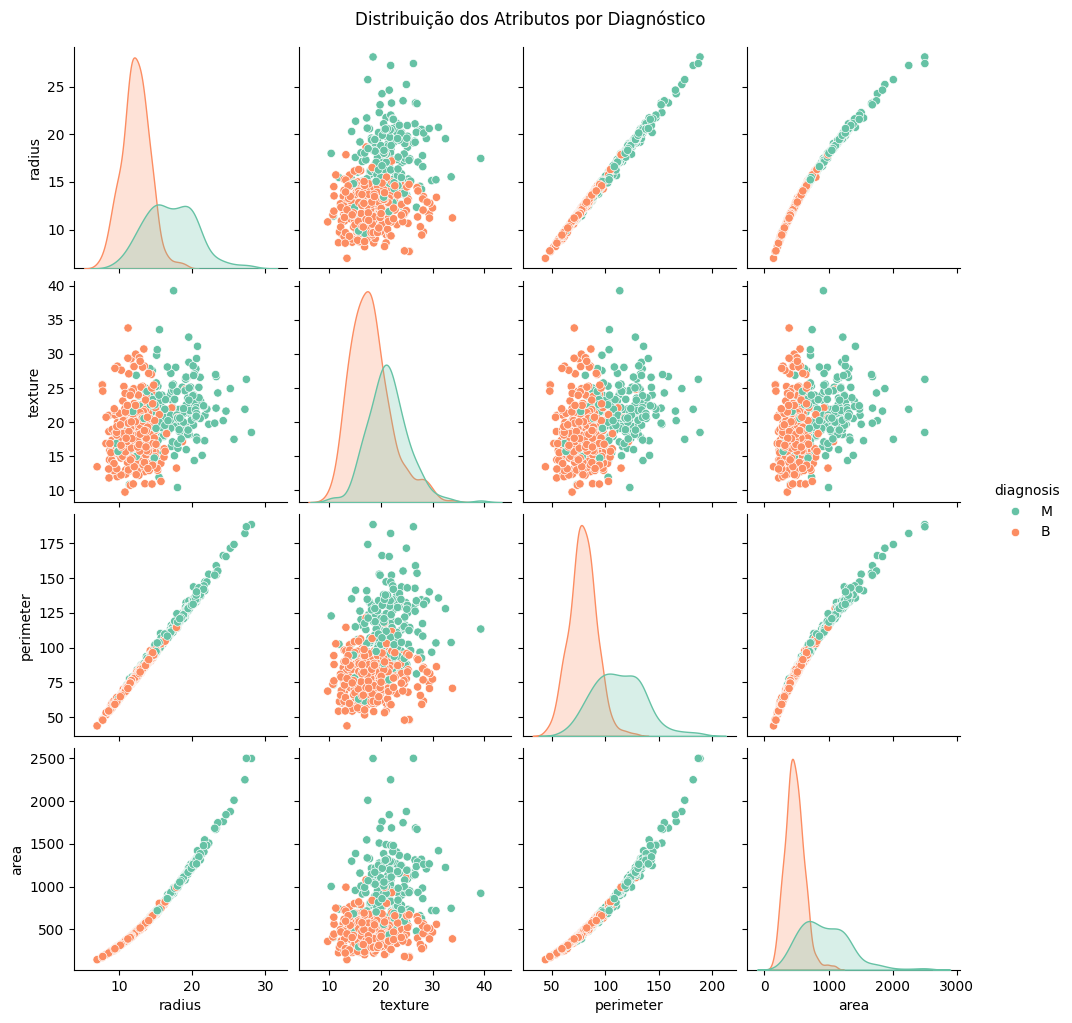

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of attributes by diagnosis
sns.pairplot(data, hue='diagnosis', vars=['radius', 'texture', 'perimeter', 'area'], palette='Set2')
plt.suptitle("Distribution of Attributes by Diagnosis", y=1.02)
plt.show()

### Train/test data split


In [67]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    data['laudo_cleaned'], data['diagnosis_encoded'], test_size=0.2, random_state=42
)

### Model acquisition


In [68]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "bert-base-cased"

# Load the pre-trained model for classification
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Tokenize data


In [69]:
# Tokenize the texts
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=512)

### Create Datasets and Dataloaders


In [70]:
from torch.utils.data import TensorDataset, DataLoader

# Converting encodings to tensors
train_inputs = torch.tensor(train_encodings['input_ids'])
train_attention_masks = torch.tensor(train_encodings['attention_mask'])
train_labels = torch.tensor(list(train_labels))

# Converting encodings to tensors
val_inputs = torch.tensor(val_encodings['input_ids'])
val_attention_masks = torch.tensor(val_encodings['attention_mask'])
val_labels = torch.tensor(list(val_labels))

# Create TensorDatasets
train_dataset = TensorDataset(train_inputs, train_attention_masks, train_labels)
val_dataset = TensorDataset(val_inputs, val_attention_masks, val_labels)

# Create DataLoaders
batch_size = 8

# Train DataLoader
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)

# Validation DataLoader
val_dataloader = DataLoader(val_dataset, shuffle=False, batch_size=batch_size)

### Optimizer and loss function


In [71]:
# Define the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

### Model training


In [72]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*Torch was not compiled with flash attention.*")

In [73]:
from tqdm import tqdm

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
epochs = 3

for epoch in range(epochs):

    # Training
    model.train()
    total_loss = 0

    # Iterate over the batches
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1} - Training"):

        # Move the tensors to the device
        batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)

        # Zero the gradients
        model.zero_grad()

        # Forward
        outputs = model(input_ids=batch_inputs, attention_mask=batch_masks, labels=batch_labels)
        loss = outputs.loss
        logits = outputs.logits

        # Backward and optimization
        loss.backward()
        optimizer.step()

        # Accumulate the loss
        total_loss += loss.item()

    # Print the average loss
    print(f"Epoch {epoch + 1} - Loss: {total_loss / len(train_dataloader)}")

    # Validation
    model.eval()
    total_correct = 0
    total_samples = 0

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the batches
        for batch in tqdm(val_dataloader, desc="Validation"):

            # Move the tensors to the device
            batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)

            # Forward
            outputs = model(input_ids=batch_inputs, attention_mask=batch_masks)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            # Calculate the accuracy
            total_correct += (predictions == batch_labels).sum().item()
            total_samples += batch_labels.size(0)

    # Print the accuracy
    print(f"Epoch {epoch + 1} - Validation Accuracy: {total_correct / total_samples:.2f}")

Epoch 1 - Training: 100%|██████████| 57/57 [00:08<00:00,  6.82it/s]


Epoch 1 - Loss: 0.25714902942510026


Validation: 100%|██████████| 15/15 [00:00<00:00, 27.35it/s]


Epoch 1 - Validation Accuracy: 0.95


Epoch 2 - Training: 100%|██████████| 57/57 [00:08<00:00,  6.89it/s]


...

Epoch 2 - Validation Accuracy: 0.95


Epoch 3 - Training: 100%|██████████| 57/57 [00:08<00:00,  6.94it/s]


Epoch 3 - Loss: 0.17511986696014278


Validation: 100%|██████████| 15/15 [00:00<00:00, 27.11it/s]

Epoch 3 - Validation Accuracy: 0.95


### Model evaluation


In [74]:
y_test = []
y_pred = []
y_proba = []

# Evaluation mode
model.eval()

# Disable gradient computation
with torch.no_grad():

    # Iterate over the batches
    for batch in val_dataloader:

        # Move the tensors to the device
        batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)

        # Forward
        outputs = model(input_ids=batch_inputs, attention_mask=batch_masks)
        logits = outputs.logits

        # True labels
        y_test.extend(batch_labels.cpu().numpy())

        # Predictions (class with the highest probability)
        preds = torch.argmax(logits, dim=-1)
        y_pred.extend(preds.cpu().numpy())

        # Positive class probabilities
        y_proba.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

#### Accuracy, Precision, Recall and F1


In [75]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")

Acurácia: 0.95
Precisão: 0.95
Recall: 0.91
F1 Score: 0.93
ROC AUC: 0.92


#### Classification report


In [76]:
from sklearn.metrics import classification_report

# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96        69
           1       0.95      0.91      0.93        45

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



#### Confusion matrix


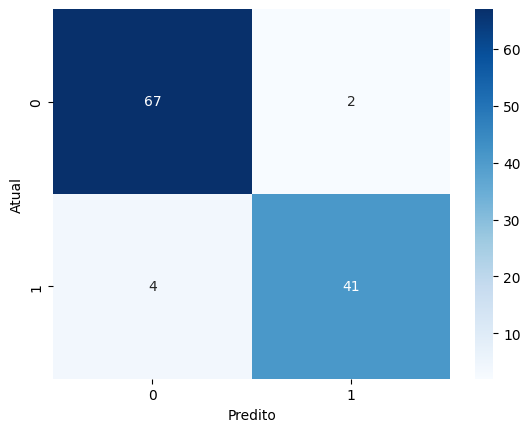

In [77]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Precision-Recall curve


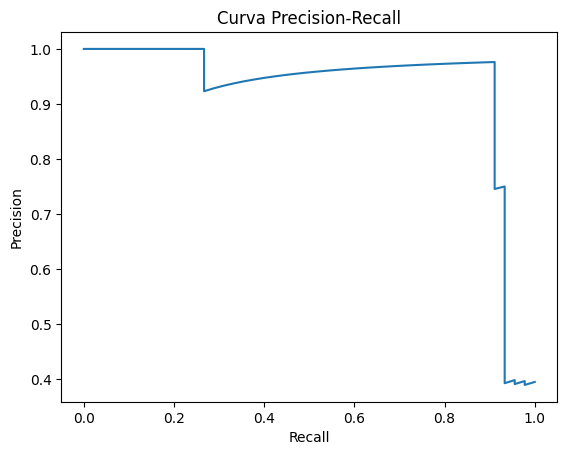

In [78]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

#### ROC curve


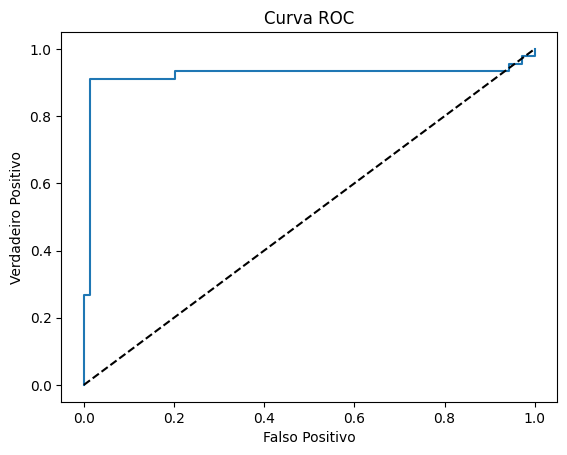

In [79]:
from sklearn.metrics import roc_curve

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

### Usage example


In [80]:
# New data
new_texts = ["""
        Patient: Luiza Moreira
        Exam: Mammography
        Exam Date: 2024-05-07

        Description:
        A lesion of approximately 27.1 mm was observed, located in the lower right quadrant, with regular borders.
        The exam suggests the lesion has benign characteristics.

        Conclusion: Benign.
        Recommendation: Monitor progress with a new exam in 6 months.
             """,
        """
        Patient: Clara Cardoso
        Exam: Mammography
        Exam Date: 2024-01-01

        Description:
        A lesion of approximately 36.0 mm was observed, located in the lower right quadrant, with regular borders.
        The exam suggests the lesion has malignant characteristics.

        Conclusion: Malignant.
        Recommendation: Refer for biopsy and oncological evaluation.
        """]

# Tokenize the new texts
new_encodings = tokenizer(new_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")

# Create DataLoader
new_dataset = TensorDataset(new_encodings['input_ids'], new_encodings['attention_mask'])
new_dataloader = DataLoader(new_dataset, batch_size=1)

# Evaluation mode
model.eval()

predictions = []

# Disable gradient computation
with torch.no_grad():

    # Iterate over the batches
    for batch in new_dataloader:

        # Move the tensors to the device
        batch_inputs, batch_masks = tuple(b.to(device) for b in batch)

        # Forward
        outputs = model(input_ids=batch_inputs, attention_mask=batch_masks)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)
        predictions.extend(preds.cpu().numpy())

# Print the predictions
print("Predictions:", predictions)

Predições: [np.int64(0), np.int64(1)]
